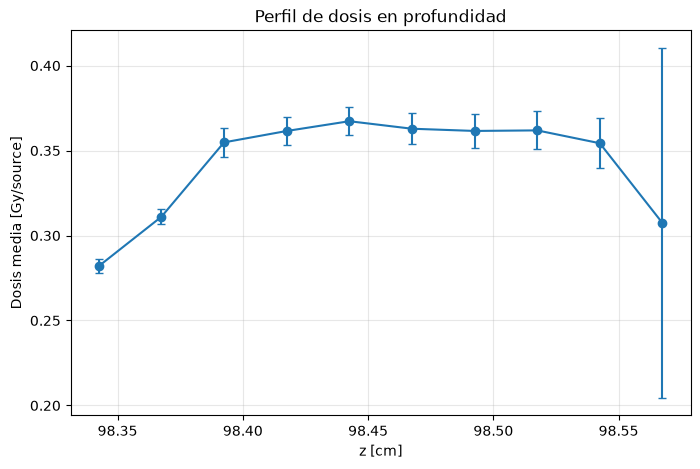

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re

archivo = "../out/histograma_dosis_CR39.out"

nx = 35
ny = 32
nz = 10

dosis = np.full((nx, ny, nz), np.nan)

ix_actual = None
iy_actual = None
leyendo = False
iz_actual = 0

z_lower = np.zeros(nz)
z_upper = np.zeros(nz)

with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    for linea in f:

        match = re.search(
            r"no\.\s*=\s*\d+\s*,\s*ix\s*=\s*(\d+)\s*,\s*iy\s*=\s*(\d+)",
            linea
        )

        if match:
            ix_actual = int(match.group(1)) - 1
            iy_actual = int(match.group(2)) - 1
            leyendo = False
            iz_actual = 0
            continue

        if "#  z-lower" in linea and "proton" in linea:
            leyendo = True
            iz_actual = 0
            continue

        if leyendo and ix_actual is not None and iy_actual is not None:

            partes = linea.split()

            if len(partes) == 4 and iz_actual < nz:
                try:
                    zl = float(partes[0])
                    zu = float(partes[1])
                    d = float(partes[2])

                    z_lower[iz_actual] = zl
                    z_upper[iz_actual] = zu

                    dosis[ix_actual, iy_actual, iz_actual] = d

                    iz_actual += 1

                    if iz_actual == nz:
                        leyendo = False

                except ValueError:
                    pass

z = (z_lower + z_upper) / 2

dosis_media = np.nanmean(dosis, axis=(0, 1))
dosis_std = np.nanstd(dosis, axis=(0, 1))

plt.figure(figsize=(8,5))

plt.errorbar(
    z,
    dosis_media,
    yerr=dosis_std,
    marker="o",
    capsize=3
)

plt.xlabel("z [cm]")
plt.ylabel("Dosis media [Gy/source]")
plt.title("Perfil de dosis en profundidad")
plt.grid(alpha=0.3)

plt.show()